# Различные полезности при обучении НС средствами <code>Keras</code>

# Загрузка и подготовка данных

## Получение данных

Описание датасета:

- CRIM     per capita crime rate by town
- ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS    proportion of non-retail business acres per town
- CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX      nitric oxides concentration (parts per 10 million)
- RM       average number of rooms per dwelling
- AGE      proportion of owner-occupied units built prior to 1940
- DIS      weighted distances to five Boston employment centres
- RAD      index of accessibility to radial highways
- TAX      full-value property-tax rate per 10,000
- PTRATIO  pupil-teacher ratio by town
- B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT    % lower status of the population
- MEDV     Median value of owner-occupied homes in $1000's

In [ ]:
from keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

X_train.shape, X_test.shape

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((404, 13), (102, 13))

In [ ]:
X_train[:1]

array([[  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
         91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
         18.72   ]])

## Масштабирование данных

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

mean, std

(array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
        5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
        9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
        1.27408168e+01]),
 array([9.22929073e+00, 2.37382770e+01, 6.80287253e+00, 2.40939633e-01,
        1.17147847e-01, 7.08908627e-01, 2.79060634e+01, 2.02770050e+00,
        8.68758849e+00, 1.66168506e+02, 2.19765689e+00, 9.39946015e+01,
        7.24556085e+00]))

In [ ]:
X_train -= mean
X_train /= std

X_test -= mean
X_test /= std

In [ ]:
X_train.mean(axis=0)

array([-1.01541438e-16,  1.09923072e-17,  1.74337992e-15, -1.26686340e-16,
       -5.25377321e-15,  6.41414864e-15,  2.98441140e-16,  4.94653823e-16,
        1.12671149e-17, -1.98136337e-16,  2.36686358e-14,  5.95679996e-15,
        6.13920356e-16])

In [ ]:
X_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# Архитектура сети


Определение сети через класс Sequential и добавление слоев в него через add

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
tf.random.set_seed(9)


model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
404 / 32

12.625

### Обучение сети

In [ ]:
%%time

num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 632.6406 - mae: 23.3265
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 599.0044 - mae: 22.6167 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 570.1565 - mae: 21.9893 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 542.6260 - mae: 21.3796 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 512.6476 - mae: 20.7081 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 478.1148 - mae: 19.9195 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 437.9825 - mae: 18.9761 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 392.2369 - mae: 17.8582 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 341.3196 - mae: 16.5309 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 287.2290 - mae: 14.9913 
CPU times: user 1.36 s, sys: 165 ms, total: 1.52 s
Wall time: 1.66 s


## Некоторые детали метода fit

Сейчас прошло 13 батчей через сеть

#### **batch_size**
> batch_size: Integer или None.<br>
Количество сэмплов за один шаг градиентного спуска<br>
Если None, то batch_size примет дефолтное значение 32<br>

In [ ]:
X_train.shape

(404, 13)

In [ ]:
404 / 32

12.625

<img src='https://drive.google.com/uc?export=view&id=1j8SxKYEi12jzJXi_bPO28q5SV9emuu0Y'>

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=64)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 242.0299 - mae: 13.5661
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 214.1859 - mae: 12.5879  
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 187.9973 - mae: 11.5746
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 164.2088 - mae: 10.5842 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 143.3481 - mae: 9.6852 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 125.7419 - mae: 8.9023 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 111.3855 - mae: 8.2542 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 99.9623 - mae: 7.7014   
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 90.9477 - mae: 7.2676 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 83.7126 - mae: 6.9215  
CPU times: user 661 ms, sys: 19.7 ms, total: 680 ms
Wall time: 1.44 s


In [ ]:
404 / 64

6.3125

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=404)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 78.7156 - mae: 6.7441
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 77.8084 - mae: 6.6986
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 76.9230 - mae: 6.6541
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 76.0576 - mae: 6.6123
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 75.2093 - mae: 6.5716
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 74.3771 - mae: 6.5318
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 73.5603 - mae: 6.4922
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 72.7576 - mae: 6.4531
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 71.9681 - mae: 6.4154
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 71.1912 - mae: 6.3780
CPU times: user 396 ms, sys: 16.1 ms, total: 412 ms
Wall time: 570 ms


#### **steps_per_epoch**

>  steps_per_epoch: Integer or `None`.<br>
        Общее количество шагов (батчей сэмплов) на одной эпохе. <br>
        Если стоит None, то steps_per_epoch равняется количеству сэмплов в датасете деленное на batch size

In [ ]:
404 / 10

40.4

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          steps_per_epoch=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70.0282 - mae: 6.2640 
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.7077 - mae: 5.9356 
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 58.0982 - mae: 5.6178 
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 53.2078 - mae: 5.3244 
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49.0012 - mae: 5.0562 
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45.4409 - mae: 4.8147 
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42.4768 - mae: 4.6014 
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.0232 - mae: 4.4176 
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.9750 - mae: 4.2695
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.2715 - mae: 4.1379 
CPU times: user 535 ms, sys: 17.2 ms, total: 553 ms
Wall time: 782 ms


#### **validation_split**

> validation_split: Float между 0 и 1.<br>
        Доля обучающих данных, которая будет использоваться как валидационная часть<br>
        Данные для валидации берутся из данных с конца в `x` и `y` **до перемешивания**.

In [ ]:
404 - 81

323

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_split=0.2)

Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27.6054 - mae: 3.6383 - val_loss: 24.0563 - val_mae: 3.7037
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.0619 - mae: 3.1820 - val_loss: 20.4301 - val_mae: 3.4241
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.6042 - mae: 2.8809 - val_loss: 17.9506 - val_mae: 3.1683
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.0789 - mae: 2.6549 - val_loss: 16.2761 - val_mae: 2.9734
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13.1971 - mae: 2.4969 - val_loss: 15.1889 - val_mae: 2.8190
Epoch 6/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.7738 - mae: 2.3558 - val_loss: 14.3663 - val_mae: 2.7212
Epoch 7/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.7155 - mae: 2.2439 - val_loss: 14.0860 - val_mae: 2.6624
Epoch 8/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.9723 - mae: 2.1741 - val_loss: 13.7284 - val_mae: 2.6109
Epoch 9/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1

#### **validation_data**

> validation_data: Данные, на которых считается функция потерь и метрики в конце каждой эпохи<br>
Модель не будет обучаться на этих данных


In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test))

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.4991 - mae: 2.3189 - val_loss: 21.8337 - val_mae: 2.9756
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.3721 - mae: 2.2187 - val_loss: 21.2680 - val_mae: 2.9329
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.1065 - mae: 2.1901 - val_loss: 20.9550 - val_mae: 2.9084
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.9641 - mae: 2.1736 - val_loss: 20.6141 - val_mae: 2.8829
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.8107 - mae: 2.1664 - val_loss: 20.3954 - val_mae: 2.8688
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10.6129 - mae: 2.1412 - val_loss: 20.2387 - val_mae: 2.8621
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.4554 - mae: 2.1288 - val_loss: 19.9899 - val_mae: 2.8499
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10.3525 - mae: 2.1224 - val_loss: 19.6963 - val_mae: 2.8343
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 

#### **validation_freq**
>validation_freq: Используется только если предоставлены validation data: `Integer`
        или `collections.abc.Container` (например, list, tuple, и др.).<br>
        `validation_freq=2` будет запускать валидацию каждые 2 эпохи.<br>
        `validation_freq=[1, 2, 10]` запускает валидацию на 1, 2 и 10 эпохах.

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test),
          validation_batch_size=X_test.shape[0],
          validation_freq=2)

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.9554 - mae: 2.0941 
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.8295 - mae: 2.0816 - val_loss: 18.7854 - val_mae: 2.7898
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.7131 - mae: 2.0711
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.6035 - mae: 2.0610 - val_loss: 18.4963 - val_mae: 2.7823
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.5508 - mae: 2.0568
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.3584 - mae: 2.0392 - val_loss: 18.1559 - val_mae: 2.7597
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.3115 - mae: 2.0375
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.1957 - mae: 2.0292 - val_loss: 17.8960 - val_mae: 2.7440
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.1232 - mae: 2.0248
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.0104 - mae: 2.0124 - val_loss: 17.6774 - val_mae: 2.724

In [ ]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test),
          validation_freq=[1, 5, 10])

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.9234 - mae: 2.0095 - val_loss: 17.4620 - val_mae: 2.7173
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.8273 - mae: 2.0009
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.7435 - mae: 1.9945
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.6675 - mae: 1.9862
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.5938 - mae: 1.9799 - val_loss: 16.8890 - val_mae: 2.6840
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.4648 - mae: 1.9618
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.4064 - mae: 1.9642
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.3225 - mae: 1.9585
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.2444 - mae: 1.9463
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.1338 - mae: 1.9394 - val_loss: 16.3320 - val_mae: 2.6503
CPU times: user 6.59 s, sys: 400 ms, total: 6.99 s
Wall time: 7.33 s


## Обучение нейросети на генераторах

Про Sequence больше [тут](https://www.tensorflow.org/api_docs/python/tf/keras/utils/Sequence)

In [ ]:
import numpy as np
import keras
from tensorflow.keras.utils import Sequence



class DataGenerator(Sequence):
    def __init__(self, data, labels, batch_size=32):
        super().__init__(**kwargs)  # Вызов конструктора базового класса
        self.batch_size = batch_size
        self.data = data
        self.labels = labels

    def __len__(self):
        return int(np.round(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        X = self.data[index * self.batch_size : (index+1) * self.batch_size]
        y = self.labels[index * self.batch_size : (index+1) * self.batch_size]

        return X, y

In [ ]:
train_datagen = DataGenerator(X_train, y_train)
test_datagen = DataGenerator(X_test, y_test)

In [ ]:
len(train_datagen)

13

In [ ]:
len(test_datagen)

3

In [ ]:
for X, y in train_datagen:
    print(X.shape)
    print(y.shape)
    break

(32, 13)
(32,)


In [ ]:
404 / 32

12.625

In [ ]:
%%time
num_epochs = 10

model.fit(train_datagen,
          epochs=num_epochs,
          validation_data=test_datagen)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.6268 - mae: 1.7983 - val_loss: 10.7502 - val_mae: 2.4661
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6976 - mae: 1.5929 - val_loss: 10.6991 - val_mae: 2.4582
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2674 - mae: 1.5824 - val_loss: 10.7027 - val_mae: 2.4591
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1303 - mae: 1.6394 - val_loss: 10.7454 - val_mae: 2.4656
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3307 - mae: 1.7946 - val_loss: 10.7134 - val_mae: 2.4586
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4177 - mae: 1.7483 - val_loss: 10.7488 - val_mae: 2.4624
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6728 - mae: 1.6467 - val_loss: 10.7609 - val_mae: 2.4653
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1117 - mae: 1.6899 - val_loss: 10.6947 - val_mae: 2.4548
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.7365

#Callbacks

**Callbacks**(Обратные вызовы) используются для отслеживания процесса обучения и выполнения каких-либо манипуляций в процессе обучения не прерывая вручную сам процесс (логгирование, сохранение моделей и тп)

Документация [здесь](https://keras.io/api/callbacks/)

## History

In [ ]:
%%time
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

num_epochs = 20

history = model.fit(train_datagen,
                    epochs=num_epochs,
                    validation_data=test_datagen)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 614.8960 - mae: 23.2231 - val_loss: 588.2353 - val_mae: 22.6914
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 558.4278 - mae: 21.9808 - val_loss: 564.5566 - val_mae: 22.1773
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 586.8498 - mae: 22.4674 - val_loss: 539.5444 - val_mae: 21.6310
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 508.3122 - mae: 20.9760 - val_loss: 510.6059 - val_mae: 20.9948
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 499.2279 - mae: 20.6687 - val_loss: 474.9685 - val_mae: 20.1994
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 455.3986 - mae: 19.7335 - val_loss: 431.5964 - val_mae: 19.1993
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 387.1425 - mae: 18.2315 - val_loss: 379.6593 - val_mae: 17.9230
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 362.9953 - mae: 17.4354 - val_loss: 320.1214 - val_mae: 16.3205
Epoch 9/20
13/13 ━━━━━━

In [ ]:
history

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

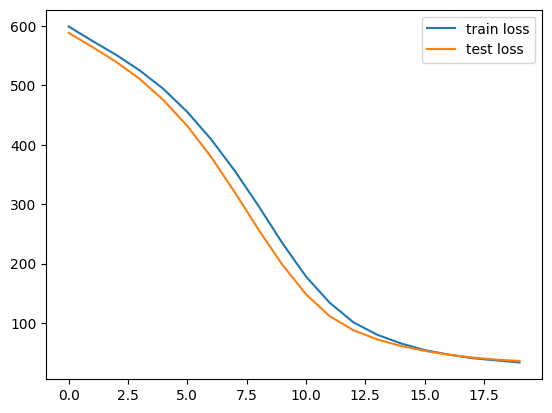

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.legend();

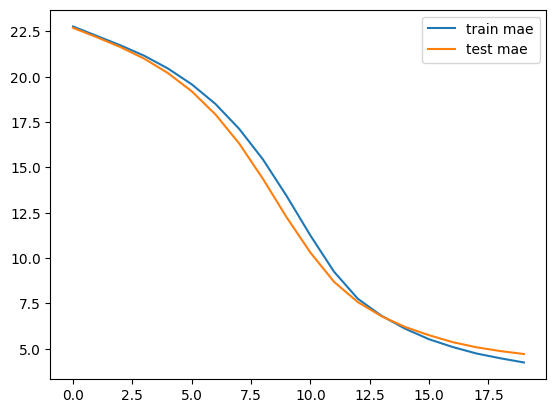

In [ ]:
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='test mae')
plt.legend();

## ModelCheckpoint

Сохранение модели после каждой эпохи.

`Filepath` может содержать именованные опции форматирования, заполняемые значениями epoch и ключами в `logs` (передаваемыми `on_epoch_end`).

К примеру: если `filepath` назван `weights.{epoch:02d}-{val_loss:.2f}.hdf5`, тогда модель будет сохраняться с номером эпохи и `validation_loss` в имени файла.

**Аргументы:**

— `filepath`: строка, путь сохранения модели

— `monitor`: параметр для мониторинга

— `verbose`: режим отображения, 0 или 1

— `save_best_only`: если `save_best_only=True`, если результат текущей эпохи хуже предыдущей, он не будет сохранен.

— `save_weights_only`: если `True`, тогда будут сохраняться только веса модели (`model.save_weights(filepath)`), в противном случае будет сохраняться вся модель (`model.save(filepath)`).

— `mode`: один из `{auto, min, max}`. Если `save_best_only=True`, решение о перезаписи текущего файла будет приниматься в зависимости от уменьшения/увеличения параметра мониторинга. Для `val_acc`, необходим `max`, для `val_loss` необходим `min`. В `auto` режиме, `mode` выбирается в зависимости от имени `monitor`.

— `save_freq`: `epoch` или integer. Если `epoch`, то сохраняется модель после каждой **эпохи**. Когда integer, то сохранение модели через это кол-во батчей.


In [ ]:
from keras import callbacks

model_checkpoint = callbacks.ModelCheckpoint(filepath='model_best_{epoch}.keras',
                                             monitor='val_mae',
                                             verbose=1,
                                             save_best_only=True,
                                             save_weights_only=False,
                                             mode='auto',
                                             save_freq='epoch'
                                             )

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train, y_train,
          epochs=5,
          validation_data=(X_test, y_test),
          callbacks=[model_checkpoint])

Epoch 1/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 8s 748ms/step - loss: 23.5513 - mae: 3.8553
Epoch 1: val_mae improved from inf to 4.41120, saving model to model_best_1.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 28.3231 - mae: 3.6818 - val_loss: 31.1095 - val_mae: 4.4112
Epoch 2/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 22.3754 - mae: 3.7957
Epoch 2: val_mae improved from 4.41120 to 4.34476, saving model to model_best_2.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27.0440 - mae: 3.6158 - val_loss: 30.4819 - val_mae: 4.3448
Epoch 3/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 21.1782 - mae: 3.6885
Epoch 3: val_mae improved from 4.34476 to 4.28249, saving model to model_best_3.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26.2250 - mae: 3.5386 - val_loss: 29.9191 - val_mae: 4.2825
Epoch 4/5
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 20.0801 - mae: 3.5887
Epoch 4: val_mae improved from 4.28249 to 4.22655, saving model to model_best_4.keras
13/13 ━━━━━━━━━━━

## Чтение модели из файла

Сравним предсказания исходной модели и загруженной из файла

In [ ]:
model.predict(X_test)[:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[11.652119],
       [15.040502],
       [21.97637 ],
       [33.48282 ],
       [26.39149 ]], dtype=float32)

In [ ]:
from keras.models import load_model
model_loaded = load_model('/content/model_best_5.keras')

model_loaded.predict(X_test)[:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[11.652119],
       [15.040502],
       [21.97637 ],
       [33.48282 ],
       [26.39149 ]], dtype=float32)

## EarlyStopping


Прекращение обучения, когда параметр `monitor` перестает улучшаться.

**Аргументы**

— `monitor`: параметр для мониторинга

— `min_delta`: минимальное значение изменения величины `monitor`, расцениваемое как улучшение, то есть, если абсолютное изменение меньше `min_delta`, то улучшение не засчитывается

— `patience`: число эпох, за которые величина `monitor` не улучшается, после которых обучение будет остановлено. Проверочные величины могут производиться не после каждой эпохи если `validation_freq` (`model.fit(validation_freq=5`)) больше единицы.

— `verbose`: режим отображения, 0 или 1.

— `mode`: один из `{auto, min, max}`. В режиме `min`, обучение остановится когда величина `monitor` перестанет уменьшаться; в режиме `max`, обучение остановится когда величина `monitor` перестанет увеличиваться; в режиме `auto`, `mode` выбирается в зависимости от имени `monitor`.

— `baseline`: значение, которое должна достичь величина `monitor`. Обучение прекратится, если модель не достигла baseline.

— `restore_best_weights`: восстанавливать ли веса модели с эпохи с лучшем значением параметра `monitor`. Если False, веса модели будут загружены из последней шага обучения.

In [ ]:
early_stop = callbacks.EarlyStopping(monitor='val_mae',
                                     min_delta=0.1,
                                     patience=2,
                                     verbose=1,
                                     mode='auto',
                                     restore_best_weights=True)


model.fit(X_train, y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[early_stop])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.9050 - mae: 3.3428 - val_loss: 28.4087 - val_mae: 4.1138
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.1659 - mae: 3.2802 - val_loss: 27.9430 - val_mae: 4.0557
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.4705 - mae: 3.2197 - val_loss: 27.5337 - val_mae: 3.9997
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.8089 - mae: 3.1608 - val_loss: 27.2104 - val_mae: 3.9474
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.1463 - mae: 3.1015 - val_loss: 26.9003 - val_mae: 3.8945
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.5105 - mae: 3.0432 - val_loss: 26.6048 - val_mae: 3.8410
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19.9079 - mae: 2.9877 - val_loss: 26.3588 - val_mae: 3.7947
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.


## ReduceLROnPlateau

Уменьшение скорости обучения, когда метрика перестала улучшаться.

**Аргументы**

— `factor`: коэффициент уменьшения скорости обучения.

— `cooldown`: число эпох после уменьшения скорости обучения, которые должны пройти, прежде чем стандартный процесс уменьшения возобновится.

— `min_lr`: нижняя граница скорости обучения

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_mae',
                                        factor=0.1,
                                        patience=0,
                                        verbose=1,
                                        mode='auto',
                                        min_delta=0.1,
                                        cooldown=2,
                                        min_lr=1e-10)

model.fit(X_train, y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[reduce_lr])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.1191 - mae: 1.9981 - val_loss: 21.7093 - val_mae: 2.9137 - learning_rate: 0.0010
Epoch 2/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.4099 - mae: 1.9138
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7857 - mae: 1.9694 - val_loss: 21.2748 - val_mae: 2.9156 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7751 - mae: 1.9591 - val_loss: 21.2495 - val_mae: 2.9116 - learning_rate: 1.0000e-04
Epoch 4/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.3299 - mae: 1.8930
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7714 - mae: 1.9588 - val_loss: 21.2375 - val_mae: 2.9071 - learning_rate: 1.0000e-04
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7627 - mae: 1.9586 - val_loss: 21.2373 - val_mae: 2.9068 - learning_rate: 1

## Кастомные коллбэки

Читать вот [тут](https://www.tensorflow.org/guide/keras/writing_your_own_callbacks)